# Immersed-boundary diffusion around a circle (two components)

This example demonstrates the directional ghost-cell **immersed boundary method (IBM)** in
`pymrm`.  The solid circle is described analytically as a `Circle` particle and
turned into immersed-boundary data by `construct_ibm_particles`; the field is advanced
with `apply_ibm` / `apply_ibm_vector`.  A non-spatial axis (`axes` / `shape`) allows
different Dirichlet wall values per component.

We solve unsteady diffusion for **two independent components** on a square domain

$$\frac{\partial u_k}{\partial t} + \nabla\cdot\left(-D\,\nabla u_k\right) = 0, \quad k=0,1$$

with the following conditions:

* **Left & right walls**: Dirichlet, $u_k = 0$.
* **Top & bottom walls**: no-flux Neumann.
* **Immersed circle** (solid obstacle) -- two-sided IBM with **per-component** wall values:
  * $u_0 = 1$ / $u_1 = 0.5$ on the **outside** (fluid),
  * $u_0 = u_1 = 0$ on the **inside** (solid).
* **Initial condition**: $u_k = 2$ everywhere.

The field array has shape `(N, N, Nc)` with `axes=(0, 1)` marking the spatial axes and
the component axis at position 2.

In [1]:
import numpy as np
import scipy as sp
from scipy.sparse import eye_array
from scipy.sparse.linalg import splu
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from IPython.display import clear_output, display

from pymrm import (construct_grad, construct_div, apply_ibm,
                   apply_ibm_vector, construct_ibm_particles,
                   Circle as Disk)

# --- Problem parameters ---
L = 1.0            # domain size
N = 81             # cells per spatial direction
Nc = 2             # number of components
D = 1.0            # diffusion coefficient (same for both components)
R = 0.25           # circle radius
cx = cy = 0.5      # circle centre
# Per-component Dirichlet values at the immersed wall:
u_out = np.array([1.0, 0.5])   # outside (fluid side)
u_in  = np.array([0.0, 0.0])   # inside  (solid side)
u_init = 2.0       # initial field value (both components)

dt = 4e-4          # time step
num_steps = 400    # number of time steps
output_interval = 40

# Field shape: (Nx, Ny, Nc) -- axes 0 and 1 are spatial, axis 2 is component
shape = (N, N, Nc)
n = N * N * Nc     # total degrees of freedom

x_f = [np.linspace(0.0, L, N + 1), np.linspace(0.0, L, N + 1)]
x_c = [0.5 * (xf[:-1] + xf[1:]) for xf in x_f]

## Analytic circle and cell classification

The circle is a `Circle((cx, cy), R)` particle; `construct_ibm_particles` classifies
the cells it covers and computes the exact wall crossings.  Passing `axes=(0, 1)` and
`shape=(N, N, Nc)` marks axis 2 as non-spatial (component), so `ibm.n_cells = N*N*Nc`,
`ibm.ns_size = Nc`, and each wall crossing spans `Nc` rows in the operator matrix.
`info.pseudo_sdf` is a sign-correct field (`< 0` inside the disk) used here only for
the solid mask in the plots; both sides share the same `ibm.coords`.

IBM wall crossings : 164
ns_size (components): 2
n_cells (full)      : 13122  = 81x81x2


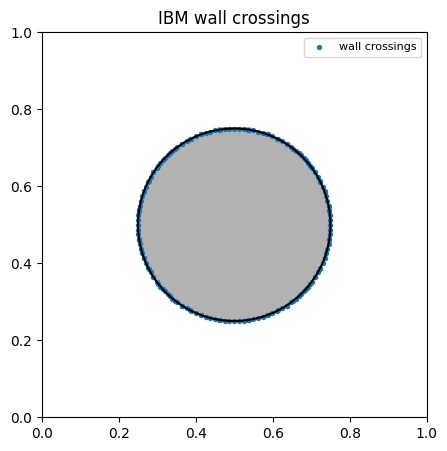

In [2]:
X, Y = np.meshgrid(x_c[0], x_c[1], indexing='ij')

# The circle is described analytically; construct_ibm_particles finds the
# exact wall crossings (its normals are unused by the Dirichlet method).
ibm, info = construct_ibm_particles([Disk((cx, cy), R)], x_c,
                                    axes=(0, 1), shape=(N, N, Nc))
sdf = info.pseudo_sdf          # sign-correct field for the solid mask / plots
print(f'IBM wall crossings : {ibm.n_crossings}')
print(f'ns_size (components): {ibm.ns_size}')
print(f'n_cells (full)      : {ibm.n_cells}  = {N}x{N}x{Nc}')

fig, ax = plt.subplots(figsize=(5, 5))
ax.pcolormesh(x_f[0], x_f[1], (sdf < 0).T, cmap='Greys', alpha=0.3, shading='flat')
ax.scatter(ibm.coords[:, 0], ibm.coords[:, 1], s=8, c='tab:blue',
           label='wall crossings')
ax.add_patch(Circle((cx, cy), R, fill=False, color='k', lw=1.5))
ax.set_aspect('equal')
ax.set_title('IBM wall crossings')
ax.legend(loc='upper right', fontsize=8)
plt.show()

## Diffusion operator with the domain boundary conditions

`construct_grad` and `construct_div` accept the full shape `(N, N, Nc)`.  Assembling
the operator along `axis=0` and `axis=1` automatically creates a block-diagonal
structure in the component axis: each component diffuses independently with the same
spatial stencil.  The domain BCs (`a * du/dn + b * u = d`) are applied identically to
both components via broadcasting.

In [3]:
bc_x = ({'a': 0, 'b': 1, 'd': 0.0}, {'a': 0, 'b': 1, 'd': 0.0})   # left/right Dirichlet 0
bc_y = ({'a': 1, 'b': 0, 'd': 0.0}, {'a': 1, 'b': 0, 'd': 0.0})   # top/bottom no-flux

diff_mat = sp.sparse.csc_array((n, n))
g_bc = np.zeros((n, 1))
for i, bc in enumerate((bc_x, bc_y)):
    grad_mat, grad_bc = construct_grad(shape, x_f[i], x_c[i], bc=bc, axis=i, format='csc')
    div_mat = construct_div(shape, x_f[i], axis=i, format='csc')
    diff_mat = diff_mat + div_mat @ (-D * grad_mat)
    g_bc = g_bc + div_mat @ (-D * grad_bc)
g_bc = np.asarray(g_bc).reshape(-1)

a_mat = (eye_array(n, format='csc') / dt) + diff_mat

## Apply the immersed boundary method

`values_outside` and `values_inside` have shape `(n_crossings, Nc)`, providing
**independent Dirichlet values per component** at each wall crossing.
`apply_ibm` handles both the outside and inside modifications, and both components,
in a single call.  The matrix is modified once and factorised once.
`apply_ibm_vector` applies the same per-row conditioning to the time-varying RHS.

In [4]:
# Per-component wall values: shape (n_crossings, Nc)
val_out = np.tile(u_out, (ibm.n_crossings, 1))   # broadcast u_out over crossings
val_in  = np.tile(u_in,  (ibm.n_crossings, 1))

a_mod_mat, g_wall = apply_ibm(a_mat, ibm, values_outside=val_out, values_inside=val_in)

lu = splu(a_mod_mat.tocsc())


def scale_rhs(vec):
    """Apply the IBM row conditioning to a right-hand-side vector."""
    return apply_ibm_vector(vec, ibm)

## Time integration (implicit Euler)

Each step solves `a_mod_mat @ u = scale_rhs(u_old/dt - g_bc) - g_wall`.  The field
`u` is a flat vector of length `N*N*Nc`; component `k` occupies every `Nc`-th element
starting at `k` (C-order, component axis last).

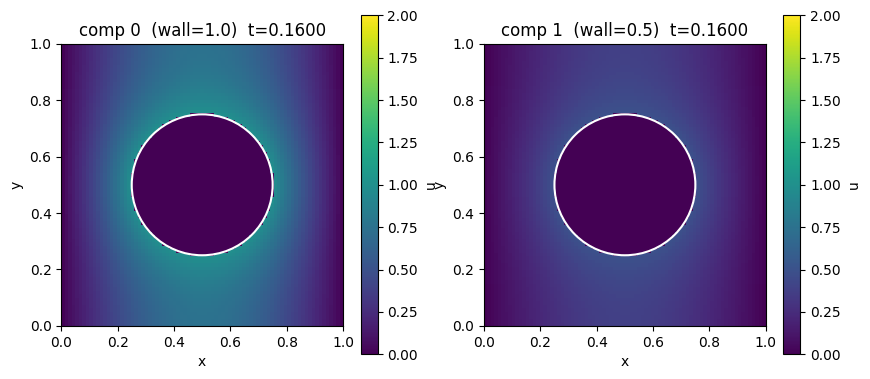

In [5]:
u = np.full(n, u_init)
solid = (sdf < 0)

fig, axs = plt.subplots(1, Nc, figsize=(5 * Nc, 4.4))
meshes = []
for k in range(Nc):
    uk = u.reshape(shape)[:, :, k]
    m = axs[k].pcolormesh(x_f[0], x_f[1], uk.T, shading='flat',
                           cmap='viridis', vmin=0, vmax=2)
    axs[k].add_patch(Circle((cx, cy), R, fill=False, color='w', lw=1.5))
    axs[k].set_aspect('equal')
    axs[k].set_xlabel('x'); axs[k].set_ylabel('y')
    axs[k].set_title(f'component {k}  (u_wall={u_out[k]:.1f})')
    fig.colorbar(m, ax=axs[k], label='u')
    meshes.append(m)

for step in range(num_steps):
    r = u / dt - g_bc
    rhs = scale_rhs(r) - g_wall
    u = lu.solve(rhs)
    if (step + 1) % output_interval == 0:
        clear_output(wait=True)
        uf = u.reshape(shape)
        for k in range(Nc):
            meshes[k].set_array(uf[:, :, k].T.ravel())
            axs[k].set_title(f'comp {k}  (wall={u_out[k]:.1f})  '
                             f't={( step + 1) * dt:.4f}')
        display(fig)
plt.close(fig)

## Result

Both components reach their respective steady states.  Component 0 approaches 1 at
the circle and 0 at the side walls; component 1 approaches 0.5 at the circle.  The
solid disk relaxes to 0 for both.

component 0  fluid min/max: 0.014 / 0.996  solid min/max: 0.000 / 0.000
component 1  fluid min/max: 0.007 / 0.498  solid min/max: 0.000 / 0.000


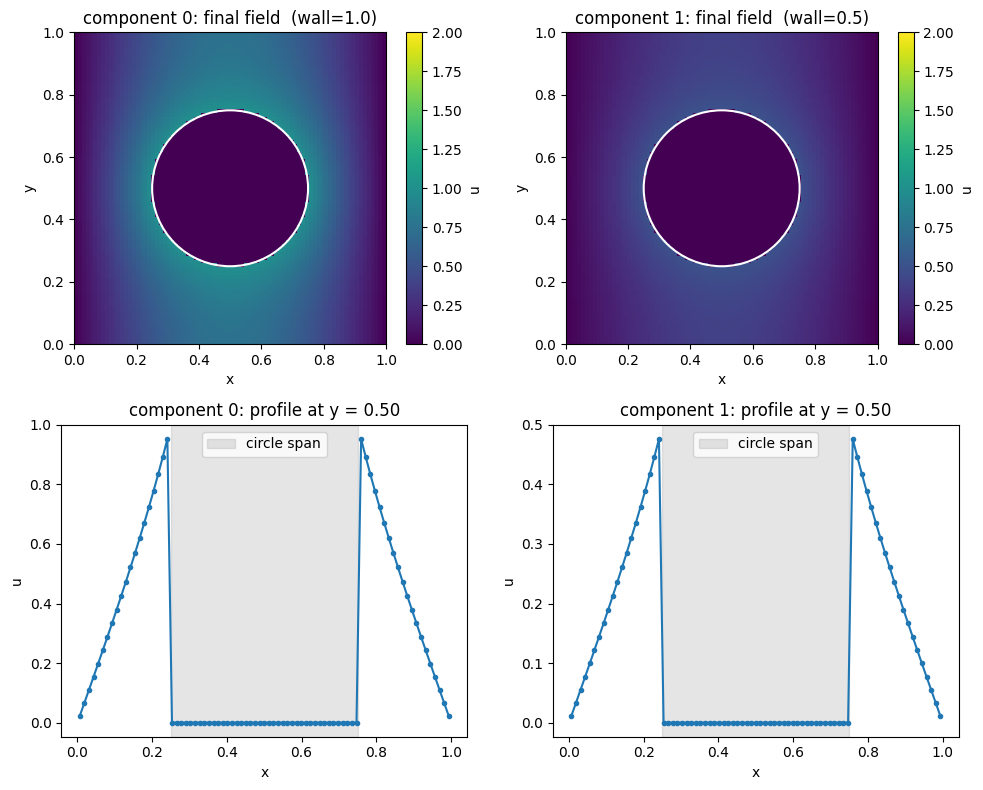

In [6]:
uf = u.reshape(shape)   # (N, N, Nc)

fig, axs = plt.subplots(2, Nc, figsize=(5 * Nc, 8))
j = N // 2

for k in range(Nc):
    # 2-D field
    m = axs[0, k].pcolormesh(x_f[0], x_f[1], uf[:, :, k].T,
                               shading='flat', cmap='viridis', vmin=0, vmax=2)
    axs[0, k].add_patch(Circle((cx, cy), R, fill=False, color='w', lw=1.5))
    axs[0, k].set_aspect('equal')
    axs[0, k].set_xlabel('x'); axs[0, k].set_ylabel('y')
    axs[0, k].set_title(f'component {k}: final field  (wall={u_out[k]:.1f})')
    fig.colorbar(m, ax=axs[0, k], label='u')

    # Centreline profile
    axs[1, k].plot(x_c[0], uf[:, j, k], '-o', ms=3)
    axs[1, k].axvspan(cx - R, cx + R, color='grey', alpha=0.2, label='circle span')
    axs[1, k].set_xlabel('x'); axs[1, k].set_ylabel('u')
    axs[1, k].set_title(f'component {k}: profile at y = {x_c[1][j]:.2f}')
    axs[1, k].legend()

    print(f'component {k}  '
          f'fluid min/max: {uf[:,:,k][~solid].min():.3f} / {uf[:,:,k][~solid].max():.3f}  '
          f'solid min/max: {uf[:,:,k][solid].min():.3f} / {uf[:,:,k][solid].max():.3f}')

plt.tight_layout()
plt.show()